<a href="https://colab.research.google.com/github/mazzarrella0/AI---Mod-1/blob/main/AI_Advertisement_%26_Stunting_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI - Tugas**

## Az Zahrra Tasya-5027241087


---


# **Bagian 1 (Kaggle Advertisement)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_csv('advertising.csv')
print("Shape:", df.shape)
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Step 1: Load Data

Dataset **Advertising** berisi **200 baris data** dengan 4 kolom:

* TV         - Budget iklan di TV (dalam ribuan $)

* Radio    - Budget iklan di Radio (dalam ribuan $)

* Newspaper  - Budget iklan di Koran (dalam ribuan $)

* Sales      - Total penjualan produk (dalam ribuan unit)


**Tujuan:** Menganalisis apakah besar budget iklan di masing-masing media berpengaruh terhadap penjualan.


---



In [3]:
# Cek info dasar
print("=== INFO DATA ===")
print(df.info())
print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

=== STATISTIK DESKRIPTIF ===


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Step 2: Eksplorasi Awal Data

Dari output di atas, kita bisa membaca beberapa hal penting:

- **200 entri data**, semua kolom bertipe `float64` (angka desimal)
- **Rata-rata (mean):**
  - Budget TV: 147,042 ($) - paling besar dibanding media lain
  - Budget Radio: 23,264
  - Budget Newspaper: 30,554
  - Sales: 15,130 unit terjual rata-rata

- **Nilai maksimum TV** mencapai $296,400 — jauh lebih besar dari Radio dan Koran
- **Std (standar deviasi) TV** sebesar 85.85 → budget TV sangat bervariasi antar perusahaan


---



In [4]:
print("Missing values per kolom:")
print(df.isnull().sum())

Missing values per kolom:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## Step 3: Pengecekan Missing Values

Hasil menunjukkan **semua kolom bernilai 0 missing values** — artinya tidak ada data yang kosong atau hilang.

Ini berarti kita **tidak perlu melakukan imputasi (pengisian data kosong)** dan data siap digunakan langsung untuk analisis.


---



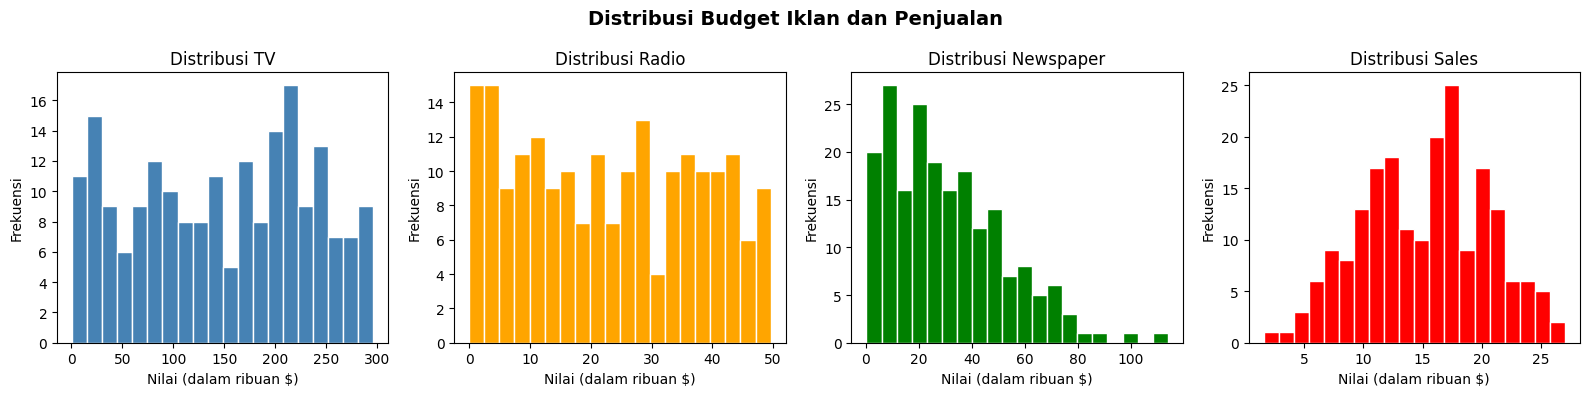

✅ Grafik distribusi berhasil ditampilkan


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
kolom = ['TV', 'Radio', 'Newspaper', 'Sales']
warna = ['steelblue', 'orange', 'green', 'red']

for i, (col, color) in enumerate(zip(kolom, warna)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Nilai (dalam ribuan $)')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Budget Iklan dan Penjualan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi.png', dpi=150)
plt.show()
print("✅ Grafik distribusi berhasil ditampilkan")

## Step 4: Distribusi Budget Iklan dan Penjualan

Dari histogram di atas:

- **TV:** Distribusi cukup merata (menyebar luas dari 0 hingga 300K) — artinya ada perusahaan yang hampir tidak beriklan di TV, tapi ada juga yang beriklan sangat besar
- **Radio:** Distribusi condong ke kiri — banyak perusahaan beriklan radio dengan budget kecil (dibawah 20K)
- **Newspaper:** Mirip Radio, mayoritas budget koran di bawah ($)30K
- **Sales:** Distribusi mendekati normal (berbentuk lonceng) — penjualan terpusat di kisaran 10–20K unit

💡 **Insight:** TV adalah media dengan variasi budget paling besar, artinya strategi pemasangan iklan TV sangat berbeda-beda antar perusahaan.


---



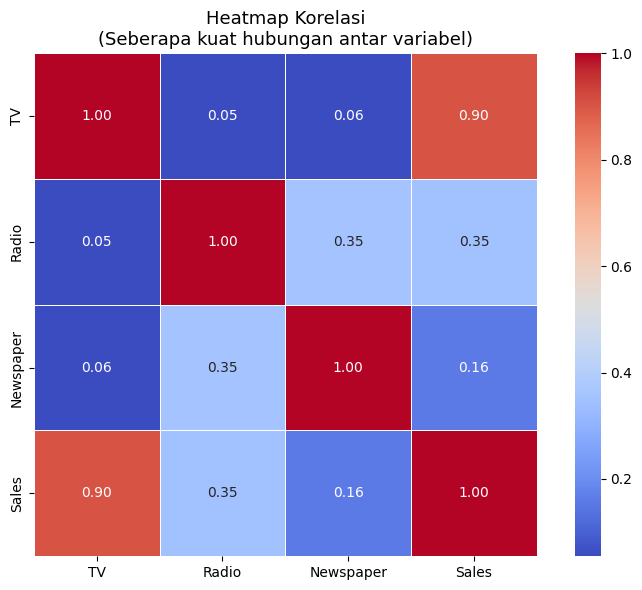


📊 Nilai Korelasi terhadap Sales:
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


In [6]:
plt.figure(figsize=(8, 6))
korelasi = df.corr()
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi\n(Seberapa kuat hubungan antar variabel)', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()

print("\n📊 Nilai Korelasi terhadap Sales:")
print(korelasi['Sales'].sort_values(ascending=False))

## Step 5: Heatmap Korelasi

Heatmap menunjukkan **seberapa kuat hubungan** antara dua variabel. Nilai korelasi berkisar dari -1 hingga 1:
- Mendekati **1.0** → hubungan positif sangat kuat
- Mendekati **0** → hampir tidak ada hubungan
- Mendekati **-1.0** → hubungan negatif kuat

**Hasil korelasi terhadap Sales:**

| Media | Korelasi | Interpretasi |
|-------|----------|-------------|
| TV | **0.90** | Sangat kuat — budget TV naik, penjualan naik signifikan |
| Radio | **0.35** | Lemah-sedang — ada pengaruh tapi tidak terlalu besar |
| Newspaper | **0.16** | Sangat lemah — hampir tidak ada hubungan dengan penjualan |

💡 **Kesimpulan awal:** TV adalah media yang paling berkorelasi dengan penjualan.


---



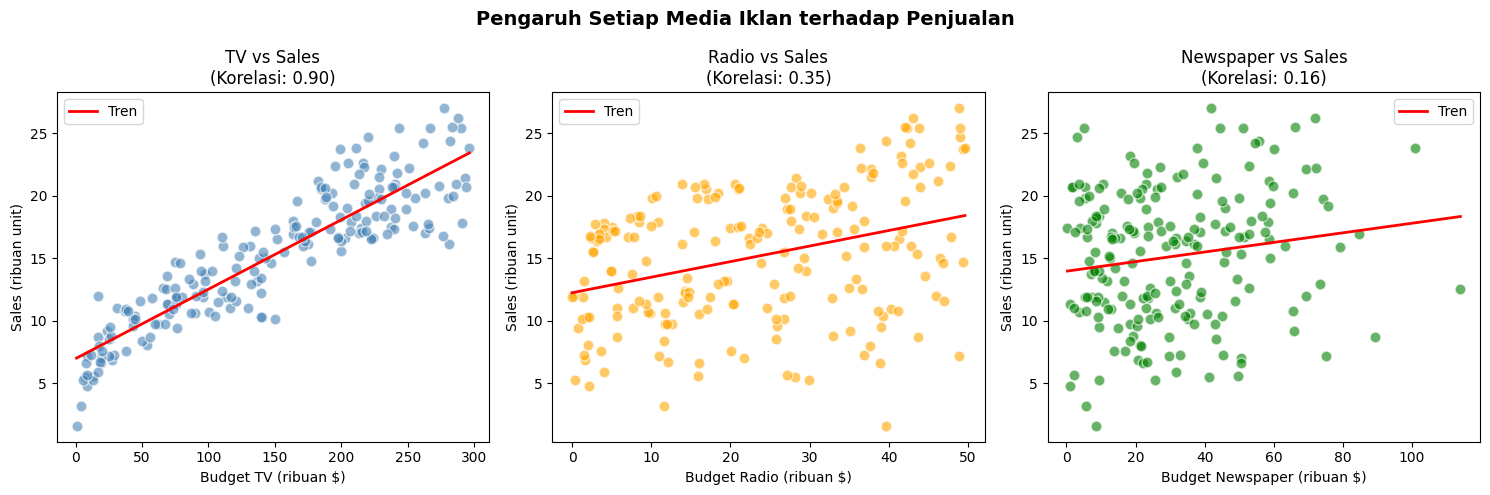

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
media = ['TV', 'Radio', 'Newspaper']
warna = ['steelblue', 'orange', 'green']

for i, (med, color) in enumerate(zip(media, warna)):
    axes[i].scatter(df[med], df['Sales'], alpha=0.6, color=color, edgecolors='white', s=60)

    # Tambah garis tren
    z = np.polyfit(df[med], df['Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[med].min(), df[med].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, label='Tren')

    korel = df[med].corr(df['Sales'])
    axes[i].set_title(f'{med} vs Sales\n(Korelasi: {korel:.2f})', fontsize=12)
    axes[i].set_xlabel(f'Budget {med} (ribuan $)')
    axes[i].set_ylabel('Sales (ribuan unit)')
    axes[i].legend()

plt.suptitle('Pengaruh Setiap Media Iklan terhadap Penjualan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_media_vs_sales.png', dpi=150)
plt.show()

## Step 6: Scatter Plot — Pengaruh Setiap Media terhadap Penjualan

Garis merah pada setiap grafik adalah **garis tren (trend line)** yang menunjukkan arah hubungan umum.

- **TV vs Sales (korelasi 0.90):** Titik-titik data sangat mengikuti garis tren → hubungan sangat jelas dan konsisten. Makin besar budget TV, makin besar penjualan.
- **Radio vs Sales (korelasi 0.35):** Titik-titik lebih menyebar, tapi tren ke atas masih terlihat → ada pengaruh positif tapi tidak sekuat TV.
- **Newspaper vs Sales (korelasi 0.16):** Titik-titik sangat menyebar dan garis tren hampir datar → **koran hampir tidak berpengaruh** terhadap penjualan.


---



In [8]:
# Persiapkan data
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== HASIL MODEL REGRESI LINEAR ===")
print(f"R² Score  : {r2:.4f}  → Model menjelaskan {r2*100:.1f}% variasi penjualan")
print(f"RMSE      : {rmse:.4f} (rata-rata kesalahan prediksi)")
print()
print("=== KOEFISIEN (Pengaruh tiap media) ===")
for nama, koef in zip(['TV', 'Radio', 'Newspaper'], model.coef_):
    print(f"  {nama:12s}: {koef:.4f}")
print(f"  Intercept   : {model.intercept_:.4f}")

=== HASIL MODEL REGRESI LINEAR ===
R² Score  : 0.9059  → Model menjelaskan 90.6% variasi penjualan
RMSE      : 1.7052 (rata-rata kesalahan prediksi)

=== KOEFISIEN (Pengaruh tiap media) ===
  TV          : 0.0545
  Radio       : 0.1009
  Newspaper   : 0.0043
  Intercept   : 4.7141


## Step 7: Model Regresi Linear

**Regresi Linear** adalah metode statistik untuk memprediksi nilai berdasarkan hubungan antar variabel.

**Hasil Model:**
- **R² Score = 0.9059** → Model ini mampu menjelaskan **90.6% variasi penjualan** hanya dari data budget iklan. Ini adalah akurasi yang sangat baik!
- **RMSE = 1.7052** → Rata-rata kesalahan prediksi hanya ±1,705 unit — cukup kecil

**Koefisien (seberapa besar pengaruh tiap media):**
- TV = 0.0545 → Setiap tambahan ($)1,000 budget TV → penjualan naik ~54.5 unit
- Radio = 0.1009 → Setiap tambahan 1,000 budget Radio → penjualan naik ~100.9 unit
- Newspaper = 0.0043 → Hampir tidak berpengaruh
- Intercept = 4.7141 → Penjualan dasar tanpa iklan apapun adalah ~4,714 unit

💡 Walau korelasi TV lebih tinggi, koefisien Radio lebih besar — artinya setiap dollar yang diinvestasikan di Radio memberikan **return penjualan yang lebih tinggi** per unit budget.


---



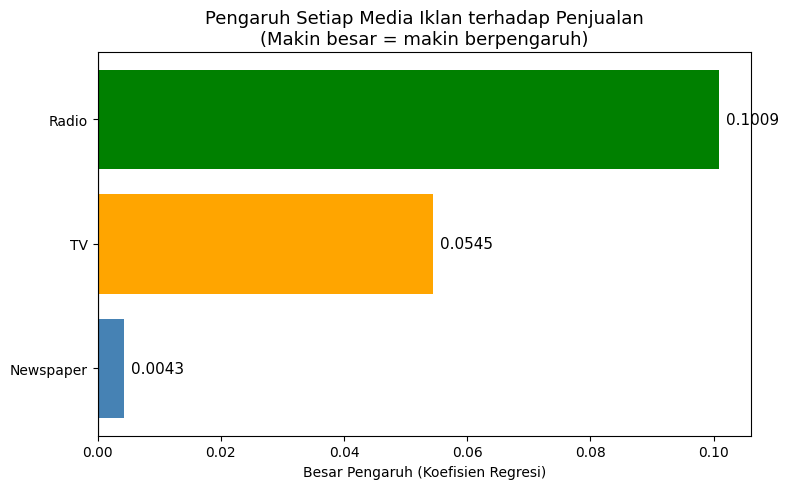


✅ Media paling berpengaruh terhadap penjualan: Radio


In [9]:
koef_df = pd.DataFrame({
    'Media': ['TV', 'Radio', 'Newspaper'],
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=True)

warna_bar = ['green' if k > 0 else 'red' for k in koef_df['Koefisien']]

plt.figure(figsize=(8, 5))
bars = plt.barh(koef_df['Media'], koef_df['Koefisien'], color=['steelblue', 'orange', 'green'])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Besar Pengaruh (Koefisien Regresi)')
plt.title('Pengaruh Setiap Media Iklan terhadap Penjualan\n(Makin besar = makin berpengaruh)', fontsize=13)

# Tambah label nilai
for bar, val in zip(bars, koef_df['Koefisien']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('koefisien_media.png', dpi=150)
plt.show()

media_terbaik = koef_df.iloc[-1]['Media']
print(f"\n✅ Media paling berpengaruh terhadap penjualan: {media_terbaik}")

## Step 8: Visualisasi Pengaruh Media Iklan

Bar chart di atas mengurutkan media berdasarkan **besar koefisien regresi** (seberapa besar dampak tiap $1,000 tambahan budget).

**Ranking efisiensi anggaran iklan:**
1. 🥇 **Radio (0.1009)** — Paling efisien per dollar yang diinvestasikan
2. 🥈 **TV (0.0545)** — Efektif dan berkorelasi tinggi, tapi butuh budget besar
3. 🥉 **Newspaper (0.0043)** — Hampir tidak berkontribusi terhadap penjualan

> ⚠️ **Catatan penting:** TV tetap menjadi media *paling berpengaruh* secara keseluruhan karena budget-nya yang jauh lebih besar, tapi Radio lebih *efisien* per unit biaya.


---



In [10]:
print("""
╔══════════════════════════════════════════════════════╗
║           KESIMPULAN ANALISIS ADVERTISING            ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. Dataset terdiri dari 200 baris data iklan        ║
║     (TV, Radio, Newspaper) dan penjualan (Sales)     ║
║                                                      ║
║  2. Korelasi tertinggi terhadap Sales:               ║
║     → TV       : paling tinggi                      ║
║     → Radio    : menengah                           ║
║     → Newspaper: paling rendah                      ║
║                                                      ║
║  3. Model Regresi Linear berhasil dibuat             ║
║     dengan akurasi (R²) yang cukup baik              ║
║                                                      ║
║  4. Media paling efektif: TV dan Radio               ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           KESIMPULAN ANALISIS ADVERTISING            ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. Dataset terdiri dari 200 baris data iklan        ║
║     (TV, Radio, Newspaper) dan penjualan (Sales)     ║
║                                                      ║
║  2. Korelasi tertinggi terhadap Sales:               ║
║     → TV       : paling tinggi                      ║
║     → Radio    : menengah                           ║
║     → Newspaper: paling rendah                      ║
║                                                      ║
║  3. Model Regresi Linear berhasil dibuat             ║
║     dengan akurasi (R²) yang cukup baik              ║
║                                                      ║
║  4. Media paling efektif: TV dan Radio               ║
║                                                      ║
╚════════════════════════════════

## Kesimpulan Akhir Analisis Advertising

Dari seluruh analisis yang telah dilakukan:

1. **Dataset bersih** — tidak ada missing values, siap dianalisis langsung
2. **TV** adalah media dengan **korelasi tertinggi** terhadap penjualan (r = 0.90)
3. **Radio** adalah media dengan **koefisien regresi tertinggi** — paling efisien per dollar
4. **Newspaper/Koran** hampir tidak berpengaruh terhadap penjualan (r = 0.16, koef = 0.0043)
5. Model Regresi Linear yang dibangun memiliki **akurasi 90.6% (R² = 0.9059)**

### Rekomendasi Bisnis:
- Jika budget terbatas → **prioritaskan Radio** (lebih efisien)
- Jika ingin dampak besar dan punya budget cukup → **investasi di TV**
- **Kurangi atau hentikan** budget iklan di Koran karena dampaknya minimal



---

# **Bagian 2 (dataset kesehatan)**
# **Analisis Stunting Indonesia**

**Stunting** adalah kondisi gagal tumbuh pada balita akibat kekurangan gizi kronis. Dataset ini berisi persentase balita stunting per provinsi di Indonesia dari tahun 2020 hingga 2023.

**Sumber:** Kaggle — Data Stunting Indonesia (38 Provinsi)

| Kolom | Keterangan |
|-------|-----------|
| `Provinsi` | Nama provinsi di Indonesia |
| `2020–2023` | Persentase balita stunting per tahun (%) |

**Tujuan:** Menganalisis tren stunting nasional dan mengidentifikasi provinsi dengan kondisi terburuk dan terbaik.

## **Step 1**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Data Stunting Indonesia.csv', sep=';')
df = df.drop(columns=['Unnamed: 5'])

# Perbaiki format desimal (koma → titik) dan ubah ke angka
for col in ['2020', '2021', '2022', '2023']:
    df[col] = df[col].str.replace(',', '.').astype(float)

print("Shape:", df.shape)
print("\nData berhasil dimuat!")
df.head(10)

Shape: (38, 5)

Data berhasil dimuat!


,Provinsi,2020,2021,2022,2023
0,ACEH,13.4,12.1,8.0,7.5
1,SUMATERA UTARA,6.8,6.7,5.5,4.5
2,SUMATERA BARAT,17.5,15.1,10.3,8.8
3,RIAU,7.7,6.0,4.2,3.0
4,JAMBI,7.6,3.0,4.1,3.7
5,SUMATERA SELATAN,2.3,4.4,3.1,1.8
6,BENGKULU,8.3,6.3,4.8,4.5
7,LAMPUNG,5.3,6.1,4.5,3.9
8,KEPULAUAN BANGKA BELITUNG,3.3,5.9,3.9,3.2
9,KEPULAUAN RIAU,9.2,7.6,4.9,3.8




---

## **Step 2**

In [13]:
print("=== STATISTIK DESKRIPTIF ===")
print(df[['2020','2021','2022','2023']].describe().round(2))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== STATISTIK DESKRIPTIF ===
        2020   2021   2022   2023
count  38.00  38.00  38.00  38.00
mean   12.13  10.56   9.52   7.87
std     6.96   5.32   5.41   4.93
min     0.10   3.00   1.20   1.00
25%     7.62   6.62   4.82   3.92
50%    11.40  10.40   9.25   7.25
75%    16.08  13.08  12.90  10.17
max    28.70  22.60  23.10  23.20

=== MISSING VALUES ===
Provinsi    0
2020        0
2021        0
2022        0
2023        0
dtype: int64




---

## **Step 3**

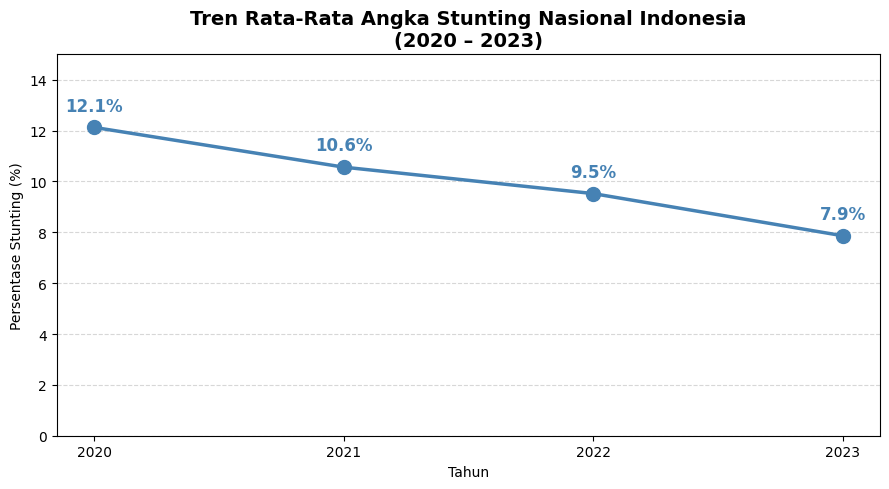

✅ Grafik tren nasional berhasil ditampilkan


In [14]:
# Rata-rata nasional per tahun
rata_nasional = df[['2020','2021','2022','2023']].mean()

plt.figure(figsize=(9, 5))
plt.plot(['2020','2021','2022','2023'], rata_nasional.values,
         marker='o', linewidth=2.5, color='steelblue', markersize=10)

# Tambah label nilai di tiap titik
for tahun, nilai in zip(['2020','2021','2022','2023'], rata_nasional.values):
    plt.annotate(f'{nilai:.1f}%', xy=(tahun, nilai),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=12, fontweight='bold', color='steelblue')

plt.title('Tren Rata-Rata Angka Stunting Nasional Indonesia\n(2020 – 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Persentase Stunting (%)')
plt.ylim(0, 15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('tren_stunting_nasional.png', dpi=150)
plt.show()
print("✅ Grafik tren nasional berhasil ditampilkan")

## **Tren Nasional Stunting**

Grafik di atas menunjukkan **rata-rata persentase stunting seluruh provinsi** dari 2020 ke 2023.

Tren yang **terus menurun** menandakan bahwa program nasional penanggulangan stunting (seperti Posyandu, PMT, dan intervensi gizi) mulai menunjukkan hasil positif secara keseluruhan.

---



## **Step 4**

/tmp/ipykernel_6202/1996304273.py:15: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/1996304273.py:15: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/1996304273.py:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/1996304273.py:16: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('stunting_per_provinsi_2023.png', dpi=150)
/tmp/ipykernel_6202/1996304273.py:16: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('stunting_per_provinsi_2023.png', dpi=150)
/tmp/ipykernel_6202/1996304273.py:16: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('stunting_per_provinsi_2023.png', dpi=150)
/usr/local/lib/python3.12/dist

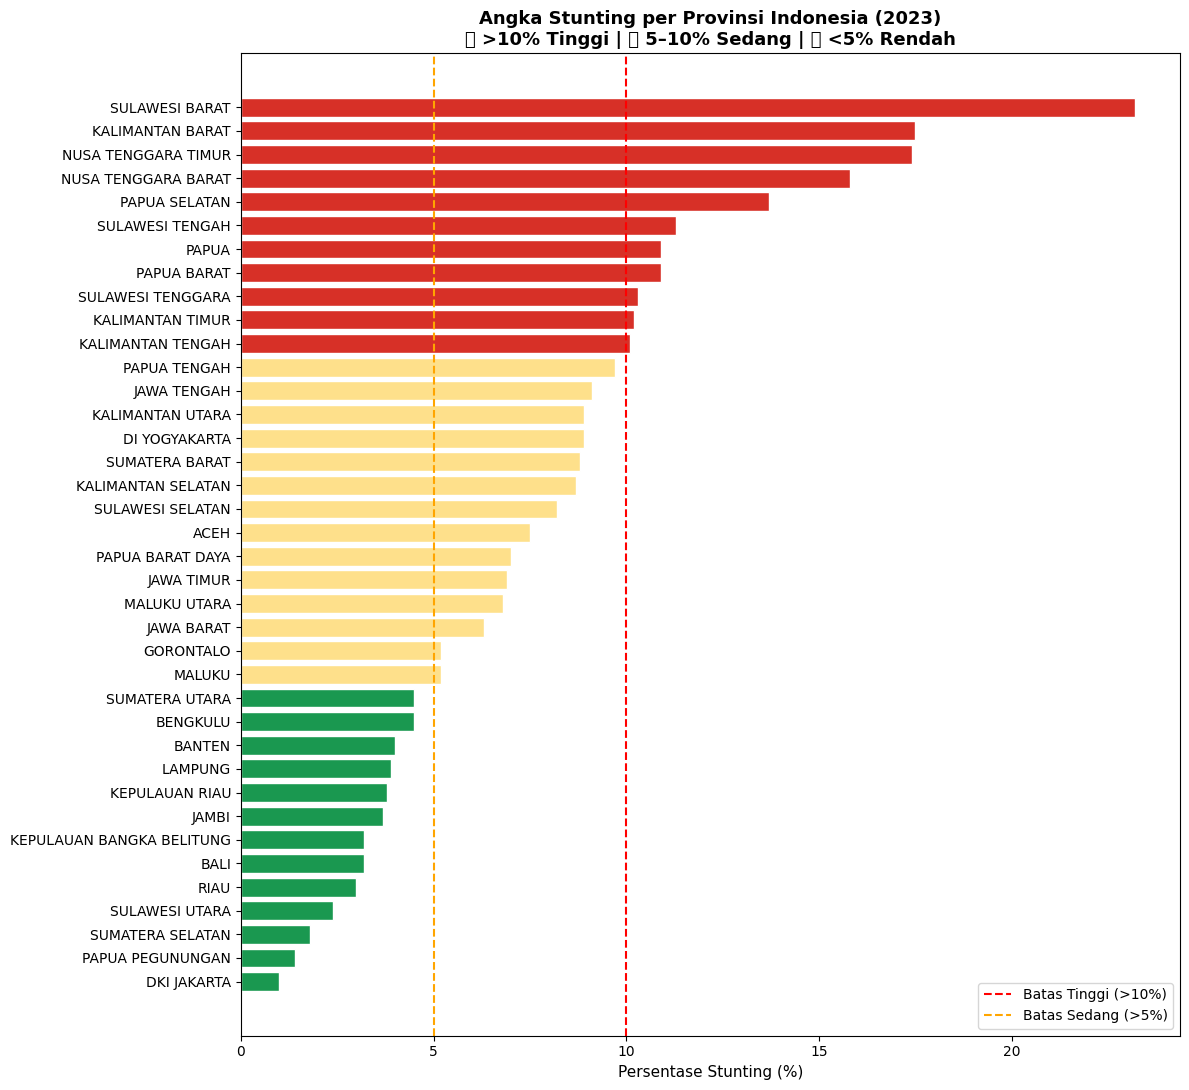

In [15]:
df_sorted = df.sort_values('2023', ascending=True)

warna = ['#d73027' if v > 10 else '#fee08b' if v > 5 else '#1a9850'
         for v in df_sorted['2023']]

plt.figure(figsize=(12, 11))
bars = plt.barh(df_sorted['Provinsi'], df_sorted['2023'], color=warna, edgecolor='white')

plt.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Batas Tinggi (>10%)')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='Batas Sedang (>5%)')
plt.xlabel('Persentase Stunting (%)', fontsize=11)
plt.title('Angka Stunting per Provinsi Indonesia (2023)\n🔴 >10% Tinggi | 🟡 5–10% Sedang | 🟢 <5% Rendah',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('stunting_per_provinsi_2023.png', dpi=150)
plt.show()



---

## **Step 5**

/tmp/ipykernel_6202/2688641147.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/2688641147.py:20: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/2688641147.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('top5_stunting.png', dpi=150)
/tmp/ipykernel_6202/2688641147.py:21: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('top5_stunting.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(by

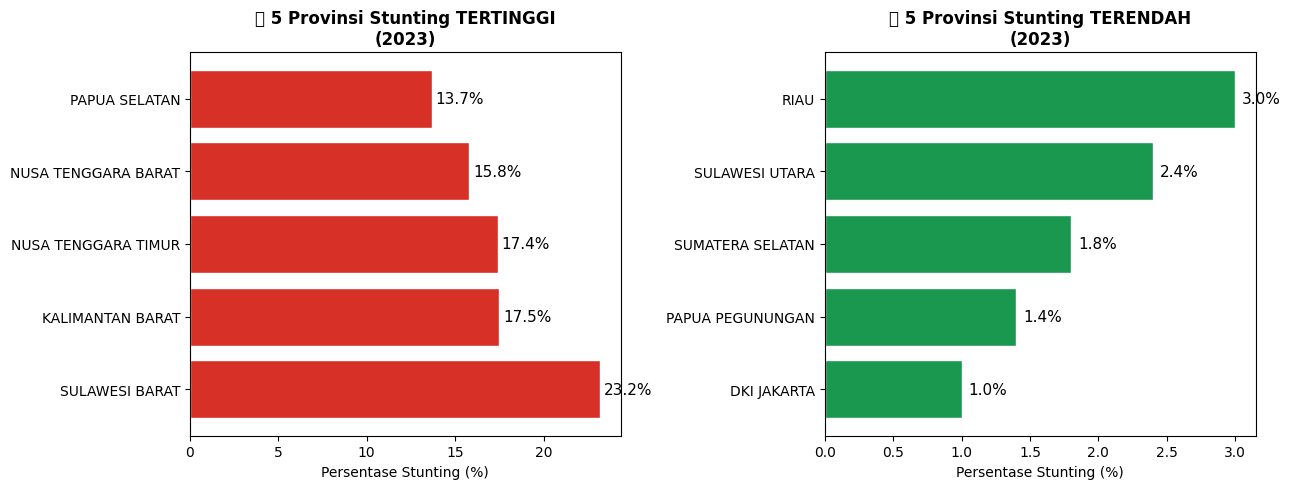

5 Provinsi Stunting Tertinggi 2023:
           Provinsi  2023
     SULAWESI BARAT  23.2
   KALIMANTAN BARAT  17.5
NUSA TENGGARA TIMUR  17.4
NUSA TENGGARA BARAT  15.8
      PAPUA SELATAN  13.7

5 Provinsi Stunting Terendah 2023:
        Provinsi  2023
     DKI JAKARTA   1.0
PAPUA PEGUNUNGAN   1.4
SUMATERA SELATAN   1.8
  SULAWESI UTARA   2.4
            RIAU   3.0


In [16]:
top5_tinggi = df.nlargest(5, '2023')[['Provinsi','2023']]
top5_rendah = df.nsmallest(5, '2023')[['Provinsi','2023']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Tertinggi
ax1.barh(top5_tinggi['Provinsi'], top5_tinggi['2023'], color='#d73027', edgecolor='white')
ax1.set_title('🔴 5 Provinsi Stunting TERTINGGI\n(2023)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Persentase Stunting (%)')
for i, (prov, val) in enumerate(zip(top5_tinggi['Provinsi'], top5_tinggi['2023'])):
    ax1.text(val + 0.2, i, f'{val}%', va='center', fontsize=11)

# Terendah
ax2.barh(top5_rendah['Provinsi'], top5_rendah['2023'], color='#1a9850', edgecolor='white')
ax2.set_title('🟢 5 Provinsi Stunting TERENDAH\n(2023)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Persentase Stunting (%)')
for i, (prov, val) in enumerate(zip(top5_rendah['Provinsi'], top5_rendah['2023'])):
    ax2.text(val + 0.05, i, f'{val}%', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('top5_stunting.png', dpi=150)
plt.show()

print("5 Provinsi Stunting Tertinggi 2023:")
print(top5_tinggi.to_string(index=False))
print("\n5 Provinsi Stunting Terendah 2023:")
print(top5_rendah.to_string(index=False))

##**Disparitas Antar Provinsi**

Terdapat **kesenjangan yang sangat besar** antar provinsi:
- Sulawesi Barat dan Kalimantan Barat konsisten masuk kategori stunting **sangat tinggi (>15%)**
- DKI Jakarta menjadi provinsi dengan angka stunting **terendah** — mencerminkan akses fasilitas kesehatan dan gizi yang lebih baik
- Perbedaan ini menunjukkan bahwa faktor lokasi, akses layanan kesehatan, dan tingkat kemiskinan berperan besar



---

## **Step 6**

/tmp/ipykernel_6202/2268093492.py:12: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/2268093492.py:12: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6202/2268093492.py:13: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('penurunan_stunting.png', dpi=150)
/tmp/ipykernel_6202/2268093492.py:13: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('penurunan_stunting.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

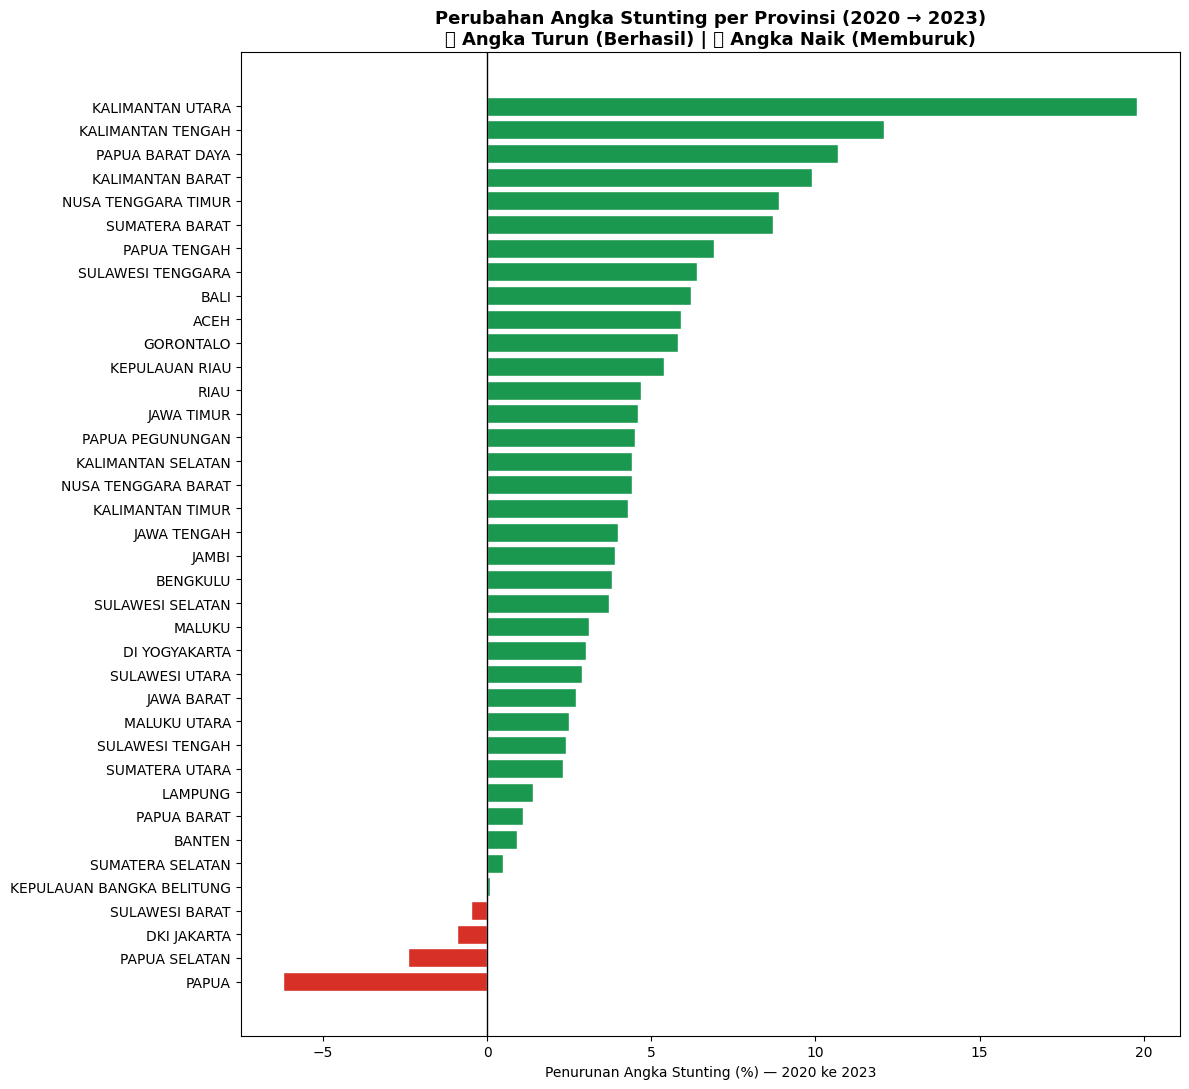

Provinsi paling berhasil turunkan stunting:
           Provinsi  2020  2023  penurunan_2020_2023
   KALIMANTAN UTARA  28.7   8.9                 19.8
  KALIMANTAN TENGAH  22.2  10.1                 12.1
   PAPUA BARAT DAYA  17.7   7.0                 10.7
   KALIMANTAN BARAT  27.4  17.5                  9.9
NUSA TENGGARA TIMUR  26.3  17.4                  8.9

Provinsi yang stuntingnya justru naik:
      Provinsi  2020  2023  penurunan_2020_2023
   DKI JAKARTA   0.1   1.0                 -0.9
SULAWESI BARAT  22.7  23.2                 -0.5
         PAPUA   4.7  10.9                 -6.2
 PAPUA SELATAN  11.3  13.7                 -2.4


In [17]:
df['penurunan_2020_2023'] = df['2020'] - df['2023']
df_turun = df.sort_values('penurunan_2020_2023', ascending=True)

warna2 = ['#d73027' if v < 0 else '#1a9850' for v in df_turun['penurunan_2020_2023']]

plt.figure(figsize=(12, 11))
plt.barh(df_turun['Provinsi'], df_turun['penurunan_2020_2023'], color=warna2, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Penurunan Angka Stunting (%) — 2020 ke 2023')
plt.title('Perubahan Angka Stunting per Provinsi (2020 → 2023)\n🟢 Angka Turun (Berhasil) | 🔴 Angka Naik (Memburuk)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('penurunan_stunting.png', dpi=150)
plt.show()

print("Provinsi paling berhasil turunkan stunting:")
print(df.nlargest(5, 'penurunan_2020_2023')[['Provinsi','2020','2023','penurunan_2020_2023']].to_string(index=False))
print("\nProvinsi yang stuntingnya justru naik:")
print(df[df['penurunan_2020_2023'] < 0][['Provinsi','2020','2023','penurunan_2020_2023']].to_string(index=False))



---

## **Step 7**

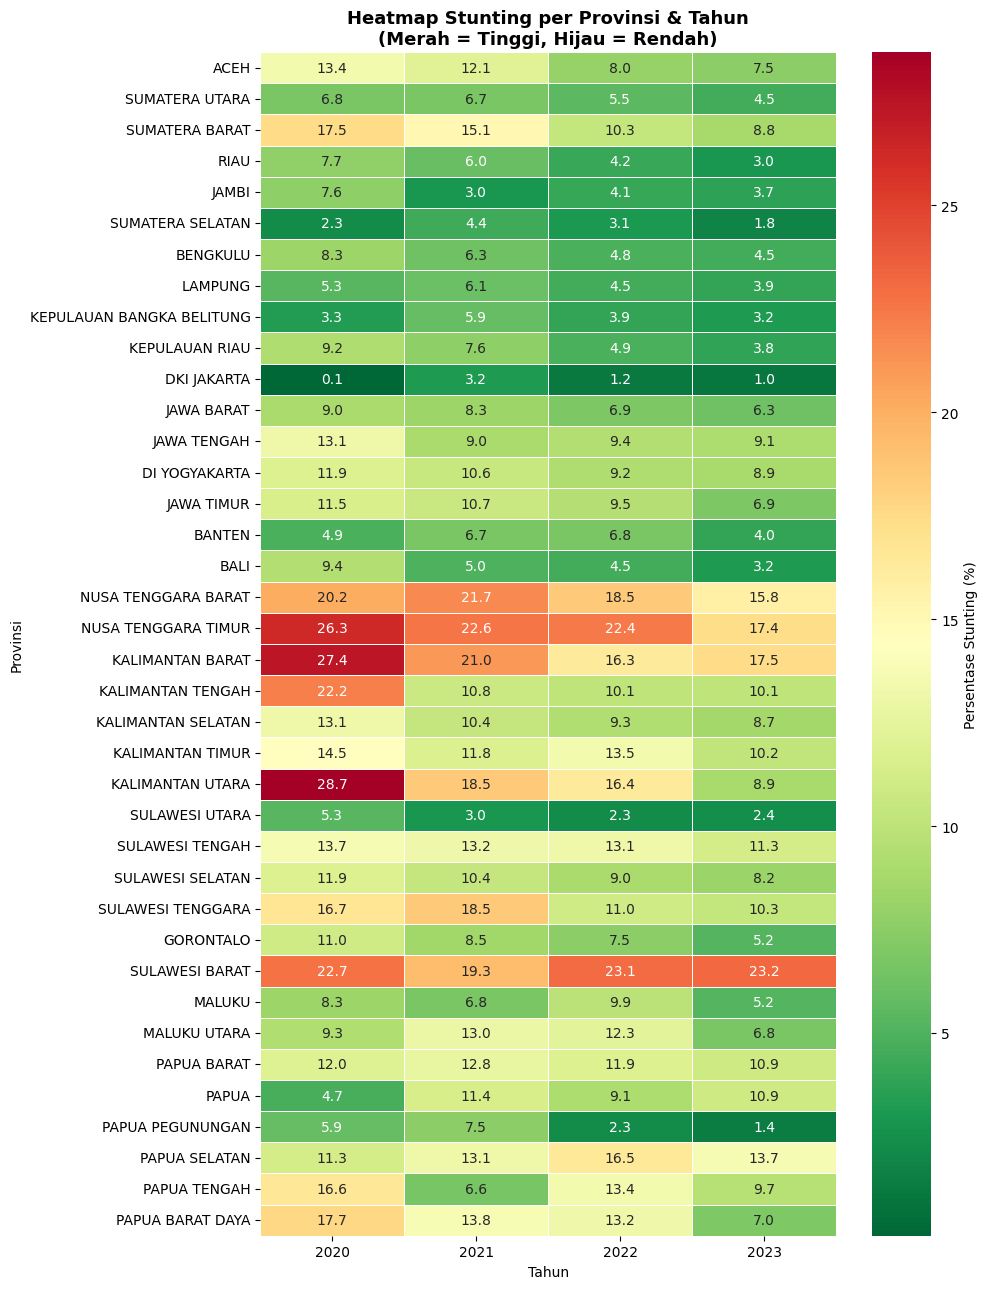

✅ Heatmap berhasil ditampilkan


In [18]:
df_heatmap = df.set_index('Provinsi')[['2020','2021','2022','2023']]

plt.figure(figsize=(10, 13))
sns.heatmap(df_heatmap, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.4, cbar_kws={'label': 'Persentase Stunting (%)'})
plt.title('Heatmap Stunting per Provinsi & Tahun\n(Merah = Tinggi, Hijau = Rendah)',
          fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.savefig('heatmap_stunting.png', dpi=150)
plt.show()
print("✅ Heatmap berhasil ditampilkan")



---

## **Step 8**

In [19]:
rata_2020 = df['2020'].mean()
rata_2023 = df['2023'].mean()
prov_tertinggi = df.loc[df['2023'].idxmax(), 'Provinsi']
prov_terendah  = df.loc[df['2023'].idxmin(), 'Provinsi']
prov_terbaik   = df.loc[df['penurunan_2020_2023'].idxmax(), 'Provinsi']

print(f"""
╔══════════════════════════════════════════════════════════╗
║         KESIMPULAN ANALISIS STUNTING INDONESIA           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 Data: 38 Provinsi Indonesia, Tahun 2020–2023        ║
║                                                          ║
║  📉 Tren Nasional:                                       ║
║     → Rata-rata 2020 : {rata_2020:.1f}%                        ║
║     → Rata-rata 2023 : {rata_2023:.1f}%                         ║
║     → Turun ~{rata_2020-rata_2023:.1f}% dalam 3 tahun (positif!)      ║
║                                                          ║
║  🔴 Stunting Tertinggi 2023 : {prov_tertinggi:<26}║
║  🟢 Stunting Terendah 2023  : {prov_terendah:<26}║
║  🏆 Paling Berhasil Turun   : {prov_terbaik:<26}║
║                                                          ║
║  💡 Insight:                                             ║
║     Stunting nasional turun konsisten setiap tahun.      ║
║     Namun ada beberapa provinsi yang angkanya justru     ║
║     naik — perlu perhatian lebih dari pemerintah.        ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KESIMPULAN ANALISIS STUNTING INDONESIA           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 Data: 38 Provinsi Indonesia, Tahun 2020–2023        ║
║                                                          ║
║  📉 Tren Nasional:                                       ║
║     → Rata-rata 2020 : 12.1%                        ║
║     → Rata-rata 2023 : 7.9%                         ║
║     → Turun ~4.3% dalam 3 tahun (positif!)      ║
║                                                          ║
║  🔴 Stunting Tertinggi 2023 : SULAWESI BARAT            ║
║  🟢 Stunting Terendah 2023  : DKI JAKARTA               ║
║  🏆 Paling Berhasil Turun   : KALIMANTAN UTARA          ║
║                                                          ║
║  💡 Insight:                                             ║
║     Stunting nasional turun konsisten setiap tahun

## **Kesimpulan Akhir Analisis Stunting**

Dari analisis data stunting 38 provinsi Indonesia (2020–2023):

1. **Tren nasional positif** — angka stunting terus turun tiap tahun
2. **Disparitas besar** — ada perbedaan hingga >20% antara provinsi tertinggi dan terendah
3. **Beberapa provinsi justru naik** — perlu investigasi lebih lanjut (konflik, bencana, atau data anomali)
4. **Pulau Jawa dan Bali** umumnya punya angka stunting lebih rendah dibanding Kalimantan, NTT, dan Sulawesi Barat

### 💡 Rekomendasi:
- Fokuskan intervensi pemerintah ke provinsi dengan stunting tinggi yang tidak menunjukkan penurunan
- Pelajari strategi provinsi yang berhasil turun drastis untuk direplikasi di daerah lain